In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Friday-WorkingHours-Morning.pcap_ISCX.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [3]:
len(df)

191033

In [4]:
df.shape

(191033, 79)

In [5]:
df.columns=df.columns.str.strip()
print(df.columns[-1])

Label


In [6]:
df["Label"].value_counts()

Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

In [7]:
df.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

In [8]:
df.select_dtypes(include="str").columns

Index(['Label'], dtype='str')

In [9]:
y=df["Label"]
x=df.drop("Label",axis=1)



In [10]:
x.shape

(191033, 78)

In [21]:
x.isnull().sum().sum()

np.int64(28)

In [19]:
np.isinf(x).sum().sum()

np.int64(216)

In [14]:
from sklearn.ensemble import IsolationForest
iso_forest=IsolationForest(contamination=0.01,random_state=42)
pred=iso_forest.fit_predict(x)
pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
pd.Series(pred).value_counts()

 1    189122
-1      1911
Name: count, dtype: int64

In [16]:
re=df.copy()
re["pred"]=pred
re["pred"]=re["pred"].map({
    1:"BEGIGN",
    -1:"ANOMALY"
})
re[["Label","pred"]].head()

,Label,pred
0,BENIGN,BEGIGN
1,BENIGN,BEGIGN
2,BENIGN,BEGIGN
3,BENIGN,BEGIGN
4,BENIGN,BEGIGN


In [17]:
pd.crosstab(re["Label"],re["pred"])

pred,ANOMALY,BEGIGN
Label,,
BENIGN,1897,187170
Bot,14,1952


In [18]:
df.groupby("Label").mean(numeric_only=True).T.head(20)

Label,BENIGN,Bot
Destination Port,6.641397e+03,1.778399e+04
Flow Duration,1.176243e+07,3.509427e+05
Total Fwd Packets,1.393711e+01,3.193795e+00
Total Backward Packets,1.654962e+01,3.343845e+00
Total Length of Fwd Packets,5.786768e+02,2.645449e+03
Total Length of Bwd Packets,2.868015e+04,6.380010e+01
Fwd Packet Length Max,1.723192e+02,4.051963e+02
Fwd Packet Length Min,2.412279e+01,2.246185e+00
Fwd Packet Length Mean,5.123897e+01,1.132755e+02
Fwd Packet Length Std,4.946036e+01,1.207496e+02


In [20]:
x_clean=x.replace([np.inf,-np.inf],np.nan)
print(x_clean.isnull().sum().sum())

244


In [22]:
x_clean=x_clean.dropna()
y_clean=y.loc[x_clean.index]

In [23]:
x_clean.shape,y_clean.shape

((190911, 78), (190911,))

In [24]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x_clean)
x_scaled.shape

(190911, 78)

In [25]:
pred=iso_forest.fit_predict(x_scaled)
pd.Series(pred).value_counts()

 1    189001
-1      1910
Name: count, dtype: int64

In [26]:
results = pd.DataFrame({
    "Actual": y_clean,
    "Predicted": pred
})

results["Predicted"] = results["Predicted"].map({
    1: "BENIGN",
    -1: "ANOMALY"
})

pd.crosstab(
    results["Actual"],
    results["Predicted"]
)

Predicted,ANOMALY,BENIGN
Actual,,
BENIGN,1910,187045
Bot,0,1956


In [27]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
y_enc=enc.fit_transform(y_clean)
print(enc.classes_)

['BENIGN' 'Bot']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

print(X_train.shape)
print(X_test.shape)

(152728, 78)
(38183, 78)


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
from sklearn.metrics import classification_report,confusion_matrix

y_pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "Bot"],
        digits=6
    )
)
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      BENIGN   0.999312  1.000000  0.999656     37792
         Bot   1.000000  0.933504  0.965608       391

    accuracy                       0.999319     38183
   macro avg   0.999656  0.966752  0.982632     38183
weighted avg   0.999320  0.999319  0.999307     38183

[[37792     0]
 [   26   365]]


In [33]:
impo_df=pd.DataFrame({
    "feature":x_clean.columns,
    "importance":rf.feature_importances_
})
impo_df=impo_df.sort_values(by="importance",ascending=False)
impo_df.head(15)

,feature,importance
0,Destination Port,0.143897
66,Init_Win_bytes_forward,0.127234
67,Init_Win_bytes_backward,0.048567
15,Flow Packets/s,0.035314
16,Flow IAT Mean,0.033723
36,Fwd Packets/s,0.031430
1,Flow Duration,0.030694
29,Bwd IAT Min,0.027619
27,Bwd IAT Std,0.026412
26,Bwd IAT Mean,0.024392


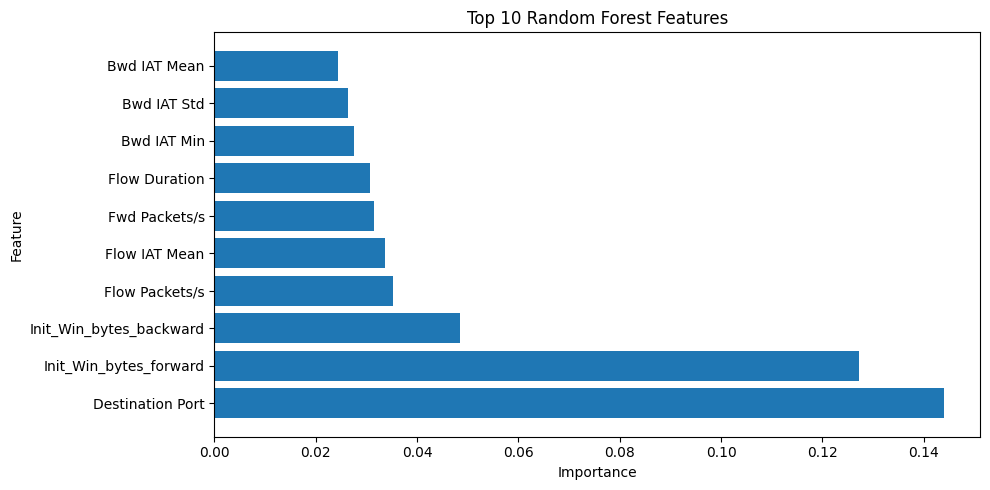

In [35]:
import matplotlib.pyplot as plt

top10 = impo_df.head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top10["feature"],
    top10["importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()